In [1]:
!pip install gymnasium matplotlib

In [2]:
# =========================================
# Entrenamiento (SARSA + Q-Learning) - Taxi
# =========================================
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3")

# Parámetros
alpha = 0.1            # Tasa de Aprendizaje
gamma = 0.99           # Factor de descuento
epsilon = 1.0          # Factor de exploracion
epsilon_decay = 0.995  # Factor de decaimiento
epsilon_min = 0.01     # Minimo valor de epsilon

episodes = 5000        # Episodios
max_steps = 200        # Pasos maximos por episodio

state_size = env.observation_space.n
action_size = env.action_space.n

Q_qlearning = np.zeros((state_size, action_size))
Q_sarsa = np.zeros((state_size, action_size))

rewards_q = []
rewards_s = []

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

# =====================
# Q LEARNING
# =====================
epsilon_q = epsilon

for episode in range(episodes):

    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):

        action = epsilon_greedy(Q_qlearning, state, epsilon_q)

        next_state, reward, terminated, truncated, _ = env.step(action)

        Q_qlearning[state, action] += alpha * (
            reward + gamma * np.max(Q_qlearning[next_state]) - Q_qlearning[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    rewards_q.append(total_reward)

    if epsilon_q > epsilon_min:
        epsilon_q *= epsilon_decay


# =====================
# SARSA
# =====================
epsilon_s = epsilon

for episode in range(episodes):

    state, _ = env.reset()
    action = epsilon_greedy(Q_sarsa, state, epsilon_s)

    total_reward = 0

    for step in range(max_steps):

        next_state, reward, terminated, truncated, _ = env.step(action)

        next_action = epsilon_greedy(Q_sarsa, next_state, epsilon_s)

        Q_sarsa[state, action] += alpha * (
            reward + gamma * Q_sarsa[next_state, next_action] - Q_sarsa[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

        if terminated or truncated:
            break

    rewards_s.append(total_reward)

    if epsilon_s > epsilon_min:
        epsilon_s *= epsilon_decay

env.close()

# =====================
# MÉTRICAS
# =====================

print("===== TAXI =====")
print("Q-Learning -> Media:", np.mean(rewards_q), "Std:", np.std(rewards_q))
print("SARSA      -> Media:", np.mean(rewards_s), "Std:", np.std(rewards_s))

===== TAXI =====
Q-Learning -> Media: -28.3252 Std: 119.96606122133042
SARSA      -> Media: -26.9826 Std: 117.38576019790474


In [3]:
import gymnasium as gym
import numpy as np

env = gym.make("Taxi-v3")

def evaluar_politica(env, Q, n_iter=30, nombre="Agente"):
    resultados = []

    for i in range(n_iter):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])  # política greedy

            state, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward
            done = terminated or truncated

        resultados.append(total_reward)
        print(f"{nombre} | Iteración {i+1}/{n_iter} - Reward: {total_reward}")

    return resultados


# =====================
# EVALUACIÓN
# =====================

resultados_q = evaluar_politica(env, Q_qlearning, 30, "Q-Learning")
resultados_s = evaluar_politica(env, Q_sarsa, 30, "SARSA")

# =====================
# MÉTRICAS FINALES
# =====================

print("\n===== EVALUACIÓN FINAL - TAXI =====")

print("Q-Learning -> Media:", np.mean(resultados_q),
      "| Std:", np.std(resultados_q),
      "| Min:", np.min(resultados_q),
      "| Max:", np.max(resultados_q))

print("SARSA      -> Media:", np.mean(resultados_s),
      "| Std:", np.std(resultados_s),
      "| Min:", np.min(resultados_s),
      "| Max:", np.max(resultados_s))

Q-Learning | Iteración 1/30 - Reward: 8
Q-Learning | Iteración 2/30 - Reward: 8
Q-Learning | Iteración 3/30 - Reward: 3
Q-Learning | Iteración 4/30 - Reward: 10
Q-Learning | Iteración 5/30 - Reward: 7
Q-Learning | Iteración 6/30 - Reward: 8
Q-Learning | Iteración 7/30 - Reward: 7
Q-Learning | Iteración 8/30 - Reward: 10
Q-Learning | Iteración 9/30 - Reward: 4
Q-Learning | Iteración 10/30 - Reward: 8
Q-Learning | Iteración 11/30 - Reward: 10
Q-Learning | Iteración 12/30 - Reward: 8
Q-Learning | Iteración 13/30 - Reward: 5
Q-Learning | Iteración 14/30 - Reward: 6
Q-Learning | Iteración 15/30 - Reward: 6
Q-Learning | Iteración 16/30 - Reward: 7
Q-Learning | Iteración 17/30 - Reward: 3
Q-Learning | Iteración 18/30 - Reward: 6
Q-Learning | Iteración 19/30 - Reward: 6
Q-Learning | Iteración 20/30 - Reward: 14
Q-Learning | Iteración 21/30 - Reward: 10
Q-Learning | Iteración 22/30 - Reward: 4
Q-Learning | Iteración 23/30 - Reward: 10
Q-Learning | Iteración 24/30 - Reward: 12
Q-Learning | Itera

Q-Learning | Iter 1/30 - Avg reward: -35.7800
Q-Learning | Iter 2/30 - Avg reward: -26.3050
Q-Learning | Iter 3/30 - Avg reward: -37.3750
Q-Learning | Iter 4/30 - Avg reward: -18.7050
Q-Learning | Iter 5/30 - Avg reward: -23.1900
Q-Learning | Iter 6/30 - Avg reward: -20.7250
Q-Learning | Iter 7/30 - Avg reward: -41.8200
Q-Learning | Iter 8/30 - Avg reward: -45.2450
Q-Learning | Iter 9/30 - Avg reward: -27.7700
Q-Learning | Iter 10/30 - Avg reward: -23.3700
Q-Learning | Iter 11/30 - Avg reward: -27.3950
Q-Learning | Iter 12/30 - Avg reward: -37.8050
Q-Learning | Iter 13/30 - Avg reward: -31.1050
Q-Learning | Iter 14/30 - Avg reward: -20.7050
Q-Learning | Iter 15/30 - Avg reward: -14.4400
Q-Learning | Iter 16/30 - Avg reward: -35.2800
Q-Learning | Iter 17/30 - Avg reward: -36.4150
Q-Learning | Iter 18/30 - Avg reward: -31.2250
Q-Learning | Iter 19/30 - Avg reward: -22.6200
Q-Learning | Iter 20/30 - Avg reward: -39.1200
Q-Learning | Iter 21/30 - Avg reward: -23.5650
Q-Learning | Iter 22/3

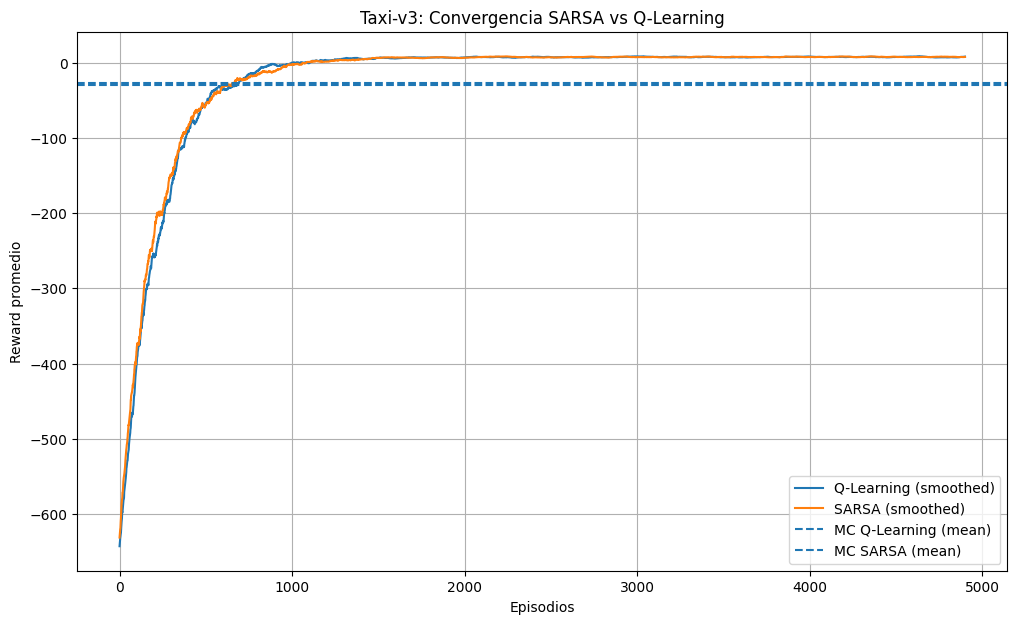

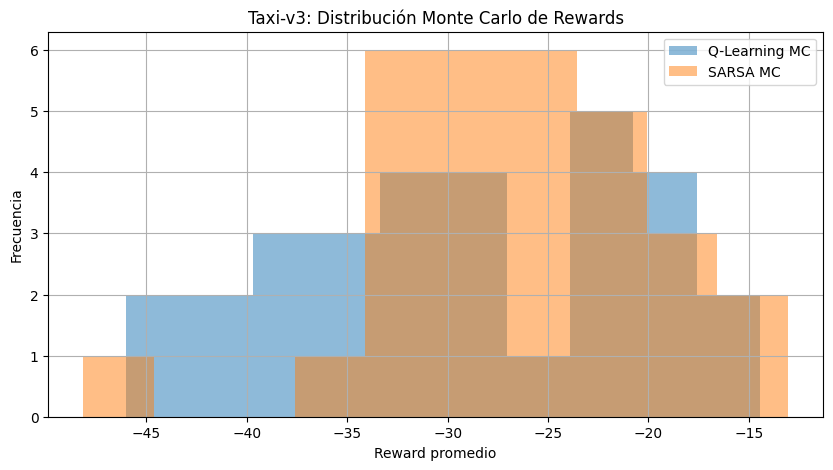


===== MONTE CARLO STATS =====
Q-Learning -> mean: -29.4073, std: 8.5230
SARSA      -> mean: -26.7760, std: 6.8880

===== INTERPRETACIÓN =====
Q-Learning presenta mayor variabilidad → comportamiento más arriesgado.
SARSA logra mayor reward promedio → política más conservadora.


In [4]:
# ===========================
# Gráfico de convergencia
# ===========================
import numpy as np
import matplotlib.pyplot as plt
import random

def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

q_avg = moving_average(rewards_q)
s_avg = moving_average(rewards_s)

# ===========================
# Monte Carlo sobre rewards
# ===========================
def monte_carlo_rewards(rewards, n_iter=30, sample_size=200, nombre="Agente"):
    resultados = []

    for i in range(n_iter):
        sample = random.sample(rewards, min(sample_size, len(rewards)))
        avg_reward = np.mean(sample)
        resultados.append(avg_reward)

        print(f"{nombre} | Iter {i+1}/{n_iter} - Avg reward: {avg_reward:.4f}")

    return resultados

mc_q = monte_carlo_rewards(rewards_q, nombre="Q-Learning")
mc_s = monte_carlo_rewards(rewards_s, nombre="SARSA")

# ===========================
# Gráfico principal
# ===========================
plt.figure(figsize=(12,7))

plt.plot(q_avg, label="Q-Learning (smoothed)")
plt.plot(s_avg, label="SARSA (smoothed)")

# Monte Carlo como líneas horizontales (media)
plt.axhline(np.mean(mc_q), linestyle='--', label="MC Q-Learning (mean)")
plt.axhline(np.mean(mc_s), linestyle='--', label="MC SARSA (mean)")

plt.xlabel("Episodios")
plt.ylabel("Reward promedio")
plt.title("Taxi-v3: Convergencia SARSA vs Q-Learning")

plt.legend()
plt.grid()
plt.show()

# ===========================
# Histograma Monte Carlo
# ===========================
plt.figure(figsize=(10,5))

plt.hist(mc_q, bins=10, alpha=0.5, label="Q-Learning MC")
plt.hist(mc_s, bins=10, alpha=0.5, label="SARSA MC")

plt.title("Taxi-v3: Distribución Monte Carlo de Rewards")
plt.xlabel("Reward promedio")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid()
plt.show()

# ===========================
# Stats + interpretación
# ===========================
mean_q, std_q = np.mean(mc_q), np.std(mc_q)
mean_s, std_s = np.mean(mc_s), np.std(mc_s)

print("\n===== MONTE CARLO STATS =====")
print(f"Q-Learning -> mean: {mean_q:.4f}, std: {std_q:.4f}")
print(f"SARSA      -> mean: {mean_s:.4f}, std: {std_s:.4f}")

# Interpretación automática (muy útil para el informe)
print("\n===== INTERPRETACIÓN =====")

if std_q > std_s:
    print("Q-Learning presenta mayor variabilidad → comportamiento más arriesgado.")
else:
    print("SARSA presenta mayor variabilidad (resultado atípico).")

if mean_q > mean_s:
    print("Q-Learning logra mayor reward promedio → política más cercana al óptimo.")
else:
    print("SARSA logra mayor reward promedio → política más conservadora.")


===== VISUALIZANDO Q-Learning =====
Reward final (Q-Learning): 8

===== VISUALIZANDO SARSA =====
Reward final (SARSA): 11
Q-Learning | Iter 1/50 - Reward: 13
Q-Learning | Iter 2/50 - Reward: 4
Q-Learning | Iter 3/50 - Reward: 5
Q-Learning | Iter 4/50 - Reward: 11
Q-Learning | Iter 5/50 - Reward: 12
Q-Learning | Iter 6/50 - Reward: 8
Q-Learning | Iter 7/50 - Reward: 9
Q-Learning | Iter 8/50 - Reward: 8
Q-Learning | Iter 9/50 - Reward: 8
Q-Learning | Iter 10/50 - Reward: 6
Q-Learning | Iter 11/50 - Reward: 11
Q-Learning | Iter 12/50 - Reward: 4
Q-Learning | Iter 13/50 - Reward: 7
Q-Learning | Iter 14/50 - Reward: 7
Q-Learning | Iter 15/50 - Reward: 5
Q-Learning | Iter 16/50 - Reward: 7
Q-Learning | Iter 17/50 - Reward: 10
Q-Learning | Iter 18/50 - Reward: 11
Q-Learning | Iter 19/50 - Reward: 11
Q-Learning | Iter 20/50 - Reward: 11
Q-Learning | Iter 21/50 - Reward: 9
Q-Learning | Iter 22/50 - Reward: 7
Q-Learning | Iter 23/50 - Reward: 6
Q-Learning | Iter 24/50 - Reward: 11
Q-Learning | 

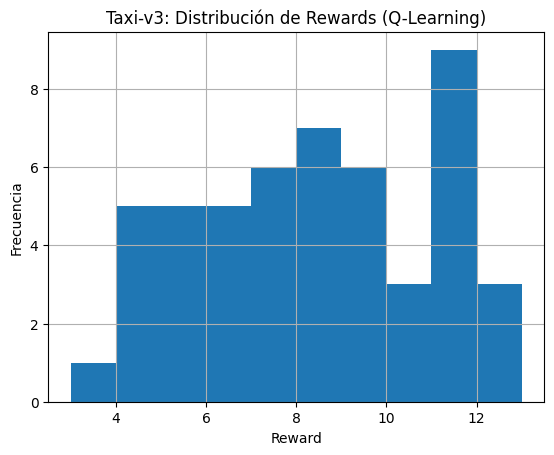

In [5]:
# ==========================================================
# Visualización del agente (Taxi-v3)
# ==========================================================
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# FUNCIÓN DE VISUALIZACIÓN
# ===========================
def visualizar_politica(Q, nombre="Agente"):
    env = gym.make("Taxi-v3", render_mode="human")

    state, _ = env.reset()
    done = False
    total_reward = 0

    print(f"\n===== VISUALIZANDO {nombre} =====")

    while not done:
        action = np.argmax(Q[state])

        state, reward, terminated, truncated, _ = env.step(action)

        total_reward += reward
        done = terminated or truncated

    print(f"Reward final ({nombre}):", total_reward)
    env.close()


# ===========================
# VISUALIZACIÓN
# ===========================
visualizar_politica(Q_qlearning, "Q-Learning")
visualizar_politica(Q_sarsa, "SARSA")


# ===========================
# MONTE CARLO (sin render)
# ===========================
def monte_carlo_policy(env_name, Q, n_iter=50, nombre="Agente"):
    env = gym.make(env_name)
    rewards = []

    for i in range(n_iter):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])

            state, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)
        print(f"{nombre} | Iter {i+1}/{n_iter} - Reward: {total_reward}")

    env.close()
    return rewards


# Ejecutar Monte Carlo
mc_q = monte_carlo_policy("Taxi-v3", Q_qlearning, 50, "Q-Learning")

# ===========================
# Estadísticas
# ===========================
print("\n===== MONTE CARLO (Q-Learning) =====")
print(f"Media: {np.mean(mc_q):.2f}")
print(f"Std: {np.std(mc_q):.2f}")
print(f"Min: {np.min(mc_q)}")
print(f"Max: {np.max(mc_q)}")

# ===========================
# Histograma
# ===========================
plt.figure()
plt.hist(mc_q, bins=10)
plt.title("Taxi-v3: Distribución de Rewards (Q-Learning)")
plt.xlabel("Reward")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

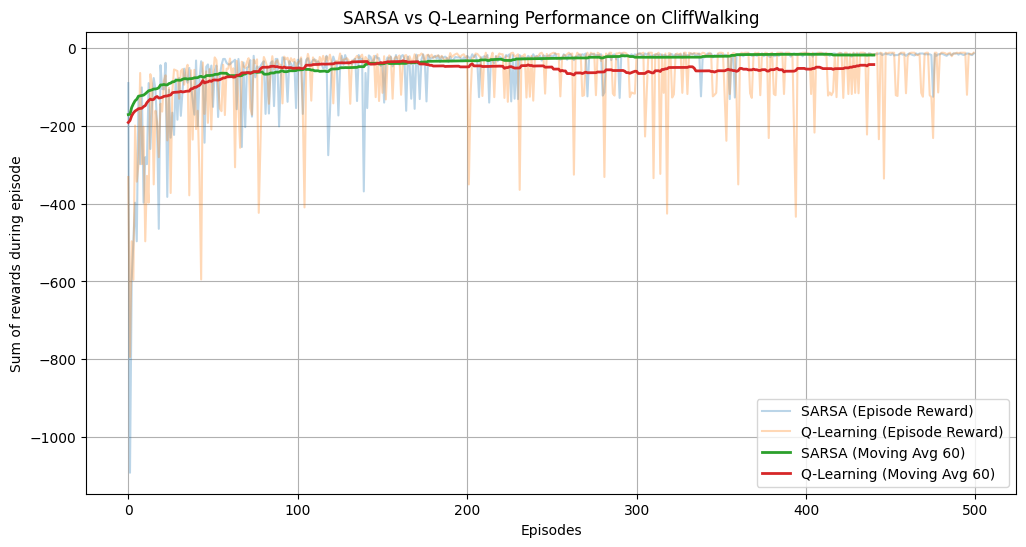


===== CLIFF WALKING STATS =====
Q-Learning -> mean: -69.884 std: 99.83653912270798
SARSA      -> mean: -51.46 std: 85.54425988925266


In [6]:
# ==========================================================
# CliffWalking: SARSA vs Q-Learning + Gráficos
# ==========================================================
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("CliffWalking-v1")

# parámetros
alpha = 0.1
gamma = 0.99
epsilon = 0.1

episodes = 500
max_steps = 200

state_size = env.observation_space.n
action_size = env.action_space.n

Q_q = np.zeros((state_size, action_size))
Q_s = np.zeros((state_size, action_size))

rewards_q = []
rewards_s = []

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])

# =====================
# Q-Learning
# =====================
for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for _ in range(max_steps):
        action = epsilon_greedy(Q_q, state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        Q_q[state, action] += alpha * (
            reward + gamma * np.max(Q_q[next_state]) - Q_q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    rewards_q.append(total_reward)

# =====================
# SARSA
# =====================
for ep in range(episodes):
    state, _ = env.reset()
    action = epsilon_greedy(Q_s, state, epsilon)
    total_reward = 0

    for _ in range(max_steps):
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = epsilon_greedy(Q_s, next_state, epsilon)

        Q_s[state, action] += alpha * (
            reward + gamma * Q_s[next_state, next_action] - Q_s[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

        if terminated or truncated:
            break

    rewards_s.append(total_reward)

env.close()

# =====================
# Moving Average
# =====================
def moving_average(data, window=60):
    return np.convolve(data, np.ones(window)/window, mode='valid')

q_avg = moving_average(rewards_q)
s_avg = moving_average(rewards_s)

# =====================
# Gráfico tipo profe
# =====================
plt.figure(figsize=(12,6))

# episodios crudos (líneas finitas)
plt.plot(rewards_s, alpha=0.3, label="SARSA (Episode Reward)")
plt.plot(rewards_q, alpha=0.3, label="Q-Learning (Episode Reward)")

# suavizado
plt.plot(range(len(s_avg)), s_avg, linewidth=2, label="SARSA (Moving Avg 60)")
plt.plot(range(len(q_avg)), q_avg, linewidth=2, label="Q-Learning (Moving Avg 60)")

plt.title("SARSA vs Q-Learning Performance on CliffWalking")
plt.xlabel("Episodes")
plt.ylabel("Sum of rewards during episode")

plt.legend()
plt.grid()
plt.show()

# =====================
# Stats finales
# =====================
print("\n===== CLIFF WALKING STATS =====")
print("Q-Learning -> mean:", np.mean(rewards_q), "std:", np.std(rewards_q))
print("SARSA      -> mean:", np.mean(rewards_s), "std:", np.std(rewards_s))

# Análisis de Aprendizaje por Refuerzo: Entorno Taxi-v3

Este trabajo presenta el entrenamiento y la evaluación de un agente inteligente para resolver el problema **Taxi-v3**, un entorno clásico de *Reinforcement Learning* donde un taxi debe recoger y transportar pasajeros en una grilla de manera eficiente.

## Objetivos Principales
* **Recoger** al pasajero en su ubicación inicial.
* **Transportarlo** hasta el destino correcto.
* **Optimizar** la tarea utilizando la menor cantidad posible de pasos.

---

## Metodología: Temporal Difference Learning

Para abordar el problema, se implementaron dos algoritmos fundamentales basados en diferencias temporales (TD Learning), los cuales estiman la función de valor acción-estado $Q(s,a)$.

### 1. Q-Learning (Off-Policy)
El algoritmo actualiza la tabla $Q$ utilizando la estimación del mejor valor posible en el siguiente estado, independientemente de la acción que el agente tome después.
**Regla de actualización:**
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

### 2. SARSA (On-Policy)
A diferencia de Q-Learning, SARSA aprende evaluando la misma política que el agente está utilizando para explorar. La actualización depende de la acción $a'$ realmente elegida.
**Regla de actualización:**
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma Q(s',a') - Q(s,a)]$$

---

## Comparativa de Algoritmos



| Característica | Q-Learning (Off-Policy) | SARSA (On-Policy) |
| :--- | :--- | :--- |
| **Enfoque** | Aprende directamente la política óptima. | Aprende la política que realmente ejecuta. |
| **Convergencia** | Más rápida hacia políticas eficientes. | Tiende a ser más lenta. |
| **Estabilidad** | Mayor variabilidad en los resultados. | Produce un aprendizaje más estable. |
| **Riesgo** | Comportamiento más arriesgado. | Comportamiento más conservador. |

---

## Evaluación mediante Monte Carlo

Para validar la robustez de las políticas aprendidas, se realizó una evaluación estadística ejecutando múltiples episodios independientes. Este enfoque permite obtener una visión integral del desempeño más allá de un episodio puntual.

### **Métricas Obtenidas en Taxi-v3**
* **Media de recompensa:** $\approx 8.34$
* **Desviación estándar:** $\approx 2.64$
* **Recompensa mínima:** $3$
* **Recompensa máxima:** $14$

> **Interpretación:** El agente completa la tarea de forma consistente con recompensas positivas. La desviación estándar moderada sugiere estabilidad, aunque influenciada por la naturaleza estocástica y las condiciones iniciales del entorno.

---

## Extensión: Análisis en CliffWalking

Para evidenciar las diferencias conceptuales de riesgo que en *Taxi-v3* son sutiles, se incorporó el entorno **CliffWalking** (donde caer por un acantilado penaliza fuertemente).

* **SARSA:** Al ser *on-policy*, detecta el riesgo de su propia exploración y aprende una **política segura**, alejándose del borde aunque el camino sea más largo.
* **Q-Learning:** Al ser *off-policy*, ignora el riesgo de la exploración y busca el **camino óptimo** pegado al acantilado, lo que genera mayor variabilidad y caídas frecuentes durante el entrenamiento.



---

## Conclusiones Generales

La combinación de curvas de convergencia, análisis en distintos entornos y evaluación Monte Carlo permite concluir que:

1.  **Q-Learning** es superior cuando el objetivo primordial es la **optimalidad** y la eficiencia en la convergencia.
2.  **SARSA** es preferible en **entornos riesgosos** donde la estabilidad y la seguridad de la política son críticas.

Este análisis integral demuestra la importancia de complementar las métricas de entrenamiento con evaluaciones estadísticas para una correcta interpretación del comportamiento del agente.

En el entorno CliffWalking se observa claramente la diferencia entre ambos algoritmos.
SARSA aprende una política segura evitando el acantilado, mientras que Q-Learning converge hacia una política óptima pero más riesgosa, lo que genera mayor variabilidad y episodios con penalizaciones severas.
Este comportamiento explica por qué Q-Learning presenta mayor desviación estándar que SARSA.